# Decision Tree Regression

## Importing the libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

## Importing the dataset

In [2]:
df = pd.read_csv('Position_Salaries.csv')
X = df.iloc[:, 1:-1].values 
y = df.iloc[:, -1].values


In [3]:
X 

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]], dtype=int64)

In [4]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000], dtype=int64)

## Training the Decision Tree Regression model on the whole dataset

In [5]:
from sklearn.tree import DecisionTreeRegressor
reg = DecisionTreeRegressor(random_state=0)
# Random state is used to ensure that the results are reproducible. It sets the seed for the random number generator used by the algorithm, which can affect the way the decision tree is built. By setting a specific random state, you can ensure that the same tree structure is generated each time you run the code, allowing for consistent results and easier debugging .
reg.fit(X, y)

DecisionTreeRegressor(random_state=0)

## Predicting a new result

In [6]:
reg.predict([[6.5]])

array([150000.])

## Visualising the Decision Tree Regression results (higher resolution)

C:\Users\HP\AppData\Local\Temp\ipykernel_13844\2894966356.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


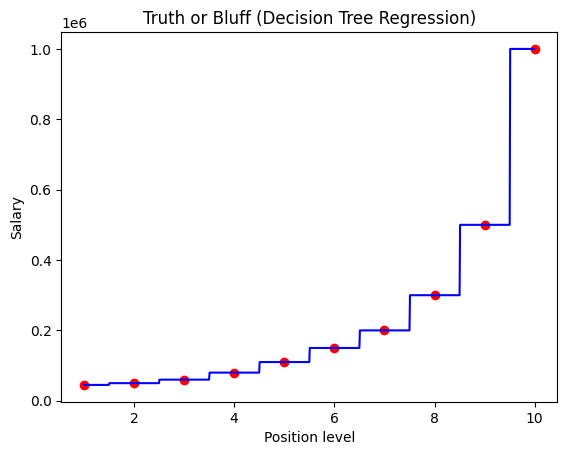

In [8]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, reg.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Decision Tree Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

# AI TIPS 


### Visualize — Low Resolution

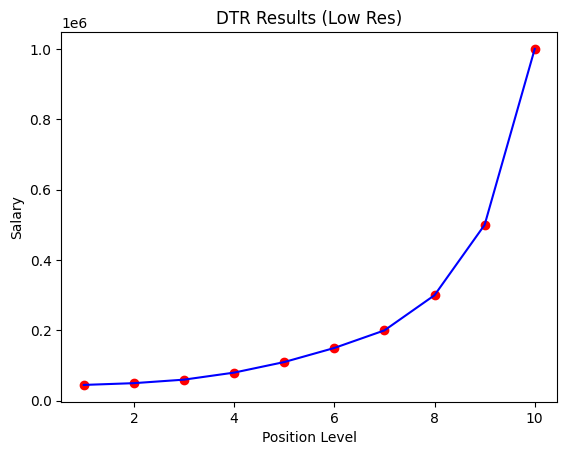

In [10]:
# Low Resolution — connects integer points
plt.scatter(X, y, color='red')
plt.plot(X, reg.predict(X),
         color='blue')
plt.title('DTR Results (Low Res)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

### R² Score & Adjusted R²

In [12]:
from sklearn.metrics import r2_score

y_pred = reg.predict(X)

# R² Score
r2 = r2_score(y, y_pred)
print(f'R² = {r2:.4f}')

# Adjusted R²
n = len(y)
k = X.shape[1]   # num of features
adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)
print(f'Adjusted R² = {adj_r2:.4f}')

R² = 1.0000
Adjusted R² = 1.0000


### Hyperparameter Tuning (Anti-Overfitting)

In [13]:
# Limit tree depth (most powerful control)
regressor = DecisionTreeRegressor(
    random_state=0,
    max_depth=3,        # max tree depth
    min_samples_split=2,# min samples to split
    min_samples_leaf=1  # min samples per leaf
)

# Grid Search for best params
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    params, cv=5, scoring='r2'
)
grid.fit(X, y)
print(grid.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


### Cross-Validation Score

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    regressor, X, y,
    cv=5,
    scoring='r2'
)
print(f"CV R²: {scores.mean():.3f}")
print(f"Std Dev: {scores.std():.3f}")

# High std = unstable = overfitting

CV R²: -44.324
Std Dev: 80.598


### Export & Visualize the Tree

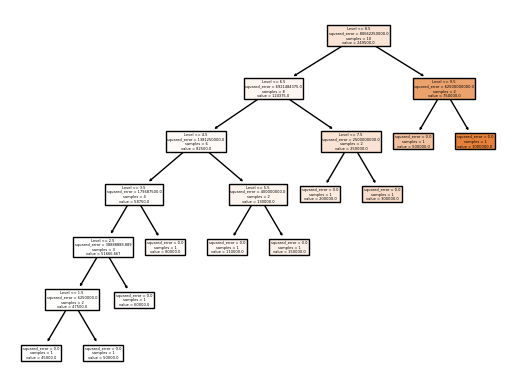

|--- Level <= 8.50
|   |--- Level <= 6.50
|   |   |--- Level <= 4.50
|   |   |   |--- Level <= 3.50
|   |   |   |   |--- Level <= 2.50
|   |   |   |   |   |--- Level <= 1.50
|   |   |   |   |   |   |--- value: [45000.00]
|   |   |   |   |   |--- Level >  1.50
|   |   |   |   |   |   |--- value: [50000.00]
|   |   |   |   |--- Level >  2.50
|   |   |   |   |   |--- value: [60000.00]
|   |   |   |--- Level >  3.50
|   |   |   |   |--- value: [80000.00]
|   |   |--- Level >  4.50
|   |   |   |--- Level <= 5.50
|   |   |   |   |--- value: [110000.00]
|   |   |   |--- Level >  5.50
|   |   |   |   |--- value: [150000.00]
|   |--- Level >  6.50
|   |   |--- Level <= 7.50
|   |   |   |--- value: [200000.00]
|   |   |--- Level >  7.50
|   |   |   |--- value: [300000.00]
|--- Level >  8.50
|   |--- Level <= 9.50
|   |   |--- value: [500000.00]
|   |--- Level >  9.50
|   |   |--- value: [1000000.00]



In [15]:
from sklearn.tree import plot_tree, export_text

# Visual plot of the tree
plot_tree(reg,
          feature_names=['Level'],
          filled=True)
plt.show()

# Text representation
print(export_text(reg,
      feature_names=['Level']))